[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/halla-ai/intronlp-2026/blob/main/notebooks/week-02.ipynb)

# 2주차 실습: 단어 빈도 집계와 분포 그리기

**목표.** 글을 잘라 세고, 불용어를 뺐을 때 상위 단어가 어떻게 바뀌는지 표와 막대그래프로 확인한다.

## 0. 준비

그래프에 한글이 네모로 나오지 않도록 한글 글꼴을 설치합니다. 한 번만 실행하면 되고 다시 시작할 필요는 없습니다.

In [1]:
# 필요한 것 설치 (Colab에서 한 번만)
!apt-get -qq install -y fonts-nanum > /dev/null

## 1. 먼저 그냥 실행해 보기

아래 셀들을 위에서부터 차례로 실행하세요. 아무것도 고치지 않아도 끝까지 돌아갑니다.

### 1-1. 잘라서 세기

출력은 `15` 와 `['제주', '바다는', '오늘도', '푸르다', '제주에서']` 입니다.

In [2]:
text = """제주 바다는 오늘도 푸르다
제주에서 고기국수를 먹었다
바다가 보이는 카페에 갔다
제주 바다는 정말 좋았다"""

tokens = text.split()
print(len(tokens))
print(tokens[:5])

15
['제주', '바다는', '오늘도', '푸르다', '제주에서']


### 1-2. 종류 세기

출력은 `13` 과 `[('제주', 2), ('바다는', 2), ('오늘도', 1), ('푸르다', 1), ('제주에서', 1)]` 입니다.

- 조각은 15개인데 종류는 13종입니다. **개수와 종류가 다릅니다**
- "바다는" 2회와 "바다가" 1회가 따로 세어집니다. 조사 때문에 같은 말이 흩어진 것입니다

In [3]:
from collections import Counter

counter = Counter(tokens)
print(len(counter))
print(counter.most_common(5))

13
[('제주', 2), ('바다는', 2), ('오늘도', 1), ('푸르다', 1), ('제주에서', 1)]


## 2. 한 지점만 바꿔 보기

아래 셀의 `TODO` 로 표시된 **한 곳만** 바꾸고 다시 실행하세요.

> 바꾸기 전 결과를 먼저 확인해 두면 무엇이 달라졌는지 비교할 수 있습니다.

빼고 싶은 말을 `stopwords` 목록에 더 넣어 봅니다. 예를 들어 `"제주"` 를 넣으면 상위 목록이 어떻게 바뀌는지 보세요.

In [5]:
stopwords = ["오늘도", "정말","바다는"]   # TODO: 빼고 싶은 말을 여기에 더 넣어 본다

# 아래는 그대로 둡니다
kept = [t for t in tokens if t not in stopwords]
print(Counter(kept).most_common(5))

[('제주', 2), ('푸르다', 1), ('제주에서', 1), ('고기국수를', 1), ('먹었다', 1)]


### 2-1. 막대그래프로 그리기

위에서 정한 `stopwords` 를 뺀 결과의 상위 10개를 그립니다. 네 문장뿐이라 앞쪽 몇 개가 크게 튀는 모양이 또렷하지 않을 것입니다. **그것 자체가 관찰 결과입니다.**

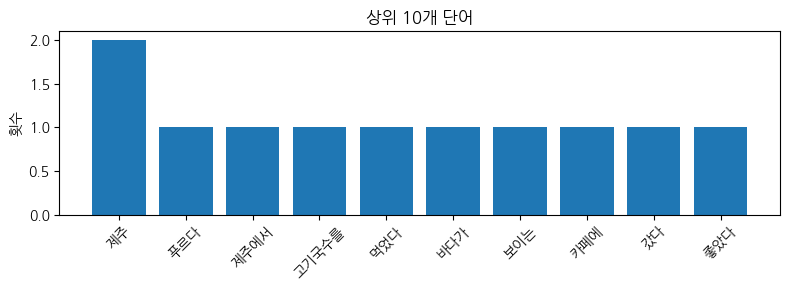

In [6]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 한글 글꼴 설정: 설치한 나눔 글꼴을 등록한다
nanum = [p for p in font_manager.findSystemFonts() if "NanumGothic" in p]
for path in nanum:
    font_manager.fontManager.addfont(path)
if nanum:
    plt.rcParams["font.family"] = "NanumGothic"

top10 = Counter(kept).most_common(10)
labels = [w for w, _ in top10]
counts = [c for _, c in top10]

plt.figure(figsize=(8, 3))
plt.bar(labels, counts)
plt.ylabel("횟수")
plt.title("상위 10개 단어")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2-2. 방언 대응쌍 열어 보기

같은 뜻을 방언과 표준어로 짝지어 둔 예입니다. 널리 알려진 인사말을 예로 든 것입니다.

실제 자료인 AI Hub 「한국어 방언 발화(제주도)」는 로그인이 필요해서 노트북이 대신 내려받을 수 없습니다. 강의 사이트의 **데이터 출처** 문서를 보고 실습 시간에 직접 열어 구조와 규모만 확인합니다.

In [7]:
dialect_pairs = [
    ("혼저 옵서예", "어서 오세요"),
    ("폭삭 속았수다", "정말 수고하셨습니다"),
    ("감수광", "가십니까"),
]

for dialect, standard in dialect_pairs:
    shared = set(dialect.split()) & set(standard.split())
    print(f"{dialect} / {standard} -> 조각 수 {len(dialect.split())} 대 {len(standard.split())}, 겹치는 조각 {sorted(shared)}")

혼저 옵서예 / 어서 오세요 -> 조각 수 2 대 2, 겹치는 조각 []
폭삭 속았수다 / 정말 수고하셨습니다 -> 조각 수 2 대 2, 겹치는 조각 []
감수광 / 가십니까 -> 조각 수 1 대 1, 겹치는 조각 []


세 쌍 모두 뜻이 같은데 **겹치는 조각이 하나도 없습니다.** 빈도표에서는 완전히 다른 말로 세어집니다. 표준어 자료로 만든 불용어 목록이 방언 자료에 맞지 않는 이유입니다.

### 심화 (2학년)

불용어 목록을 파일에 적어 두고 읽어 오는 방식입니다. 목록을 넣었을 때와 뺐을 때의 상위 10개를 두 표로 나란히 놓습니다. 그대로 실행해도 돌아갑니다.

처음 실행하면 `stopwords.txt` 가 만들어집니다. 화면 왼쪽 **폴더** 아이콘에서 이 파일을 두 번 눌러 열고, 한 줄에 한 말씩 고쳐 저장한 뒤 셀을 다시 실행해 비교합니다. 이미 있는 파일은 덮어쓰지 않으니 고친 내용이 그대로 쓰입니다.

In [9]:
import os
import pandas as pd

if not os.path.exists("stopwords.txt"):  # 처음 한 번만 기본 목록을 만든다
    with open("stopwords.txt", "w", encoding="utf-8") as f:
        f.write("오늘도\n정말\n제주\n")

with open("stopwords.txt", encoding="utf-8") as f:
    file_stopwords = [line.strip() for line in f if line.strip()]

before = pd.DataFrame(Counter(tokens).most_common(10), columns=["빼기 전", "횟수"])
after = pd.DataFrame(
    Counter(t for t in tokens if t not in file_stopwords).most_common(10),
    columns=["뺀 뒤", "횟수"],
)
print("불용어:", file_stopwords)
pd.concat([before, after], axis=1)

불용어: ['오늘도', '정말', '제주', '바다는']


,빼기 전,횟수,뺀 뒤,횟수
0,제주,2,푸르다,1.0
1,바다는,2,제주에서,1.0
2,오늘도,1,고기국수를,1.0
3,푸르다,1,먹었다,1.0
4,제주에서,1,바다가,1.0
5,고기국수를,1,보이는,1.0
6,먹었다,1,카페에,1.0
7,바다가,1,갔다,1.0
8,보이는,1,좋았다,1.0
9,카페에,1,NaN,NaN


## 3. 확인 질문

1. 조각 수와 종류 수를 옮겨 적으세요. 두 숫자가 왜 다른가요?
2. `stopwords` 에 무엇을 넣었고 왜 넣었나요? 넣기 전과 뒤에 상위 목록이 어떻게 달라졌나요?
3. 방언과 표준어 표기 차이가 빈도표를 어떻게 흔드는지 한 줄로 적으세요.

답은 아래 셀에 글로 적으면 됩니다. 코드가 아니어도 됩니다.

1.조각 수:15, 종류 수:13 동의어 제주와 바다는이 있기 때문이다.  
2.stopwords에 바다는을 추가하였다. 상위목록에 있는 단어를 불용어로 추가했을때 표가 어떻게 변하는지 보고싶었다.  넣은 후에는 푸르다와 제주에서가 1회로 상위목록에 올랐다.  
3.같은 의미의 말이더라도 방언과 표준어의 표현방식이 다르기 때문에 완전히 다른 말로 세어집니다.

## 4. 제출

1. 상단 메뉴 **파일 > .ipynb 다운로드** 로 이 노트북을 내려받습니다
2. [저장소](https://github.com/halla-ai/intronlp-2026)의 `assignments/week-02/<내 학번>/` 에 업로드합니다
3. Pull Request를 엽니다

자세한 방법은 강의 사이트의 **과제 제출** 문서에 있습니다.

---

**막혔나요?** 오류 메시지의 마지막 줄을 먼저 읽어 보세요. 그래도 안 되면 AI Professor 튜터에게 묻고, 그래도 막히면 저장소 Issues에 남기세요.